In [ ]:
from google.colab import files
import io

uploaded = files.upload()

Saving all_patients_heart_sim_results.csv to all_patients_heart_sim_results.csv


In [ ]:
# --- Standard Libraries ---
import math
import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- Scikit-learn ---
from sklearn.preprocessing import RobustScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, calinski_harabasz_score

# --- Statistical testing ---
from scipy.stats import kruskal, mannwhitneyu, shapiro

# --- Post-hoc testing ---
try:
    import scikit_posthocs as sp
except ImportError:
    !pip install scikit-posthocs -q
    import scikit_posthocs as sp

# --- Interactive plotting ---
import plotly.express as px
import plotly.graph_objects as go
from scipy.spatial import ConvexHull


In [ ]:
pe = pd.read_csv('all_patients_heart_sim_results.csv')
pe.head()
# healthy = pd.read_csv('healthy_heart_sim_results.csv')

FileNotFoundError: [Errno 2] No such file or directory: 'all_patients_heart_sim_results.csv'

## 1. Understand the data

- Check cols names, data types, missing values
- Clean data: handle missing values, outliers
- Normalize/standardize: numeric features (lung variables use different units)
- Encode categorical variables



Notes:
- Missing data has been handled

In [ ]:
pe.isna().sum()

,0
patientIndex,0
PtKey,0
BSA,0
HR,0
tc,0
HI,0
LVEDVi,0
LVESVi,0
RVEDVi,0
RVESVi,0


In [ ]:
# drop the row with nan value for simplicity
pe = pe.dropna(axis=1).reset_index(drop=True)
pe.isna().sum()

,0
patientIndex,0
PtKey,0
BSA,0
HR,0
tc,0
HI,0
LVEDVi,0
LVESVi,0
RVEDVi,0
RVESVi,0


In [ ]:
## Check data types
pe.dtypes

,0
patientIndex,int64
PtKey,int64
BSA,float64
HR,float64
tc,float64
HI,float64
LVEDVi,float64
LVESVi,float64
RVEDVi,float64
RVESVi,float64


❗there is an outlier, patient #40 is exhibiting extremely high values for cardiac output, we will remove them

In [ ]:
pe = pe[pe["patientIndex"] != 40]

### Normalize / Standardize Outliers

- Outliers can distort scaling, clustering distance metrics, and PCA projections
- We will use box plot to visualize the distribution of numerical data

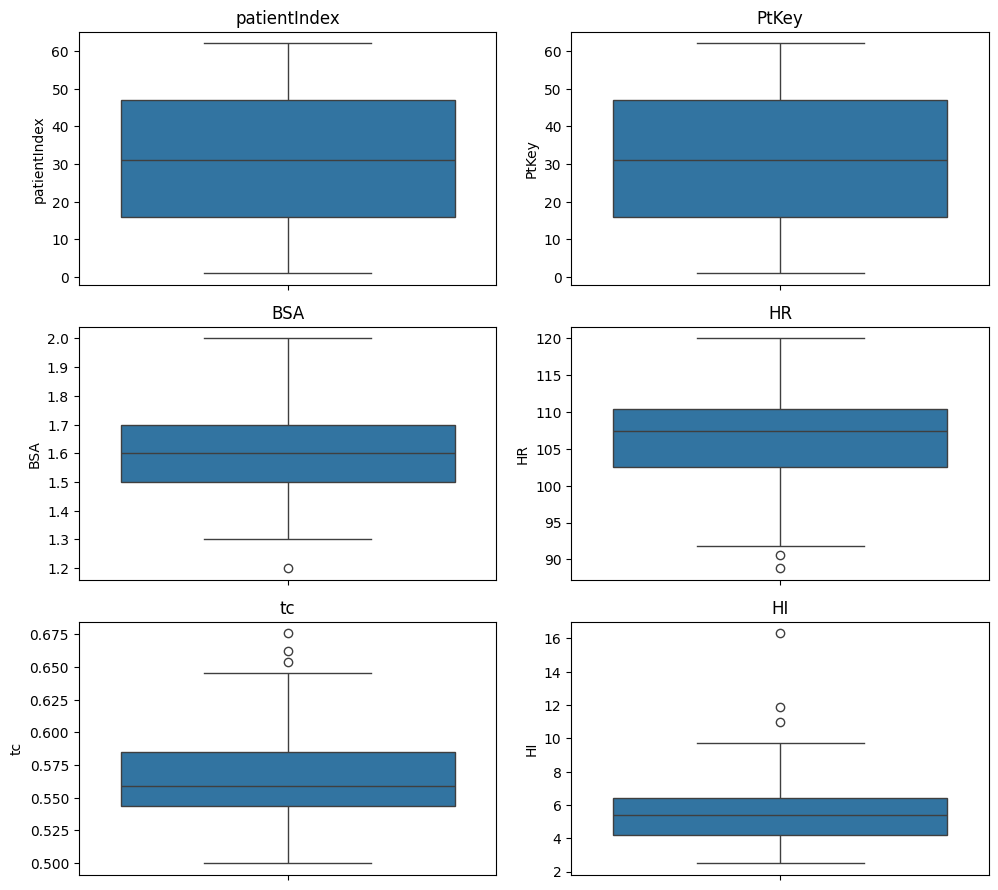

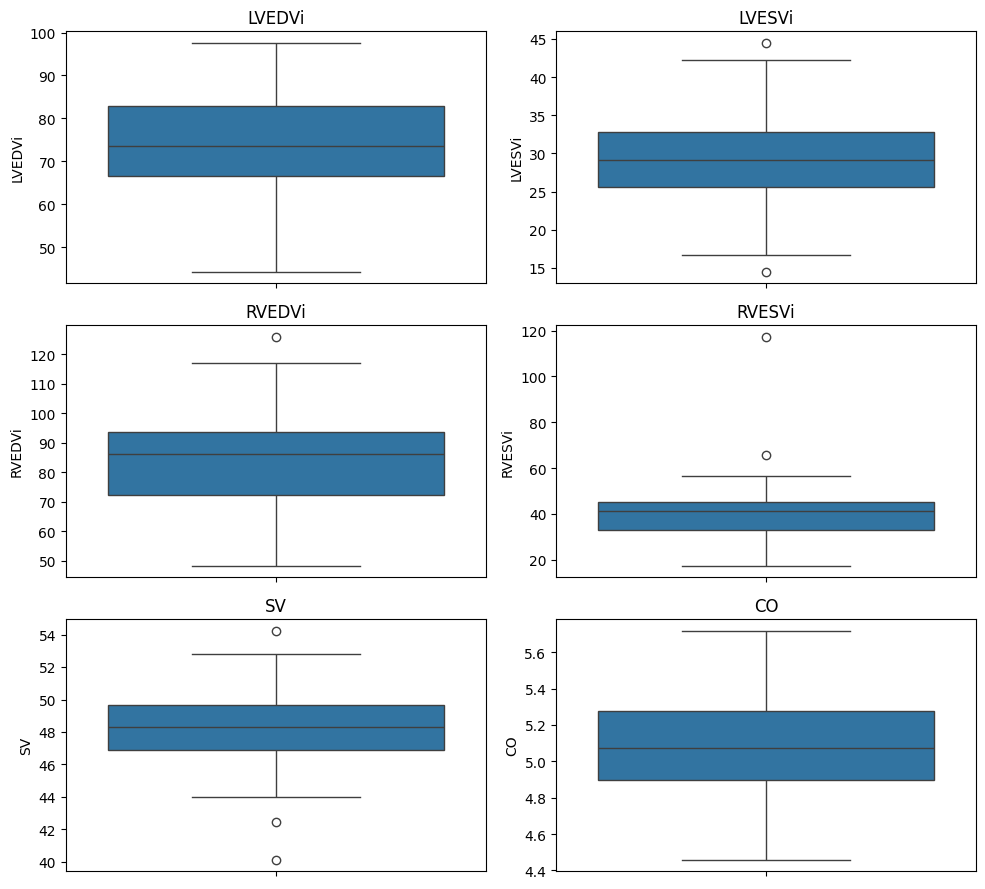

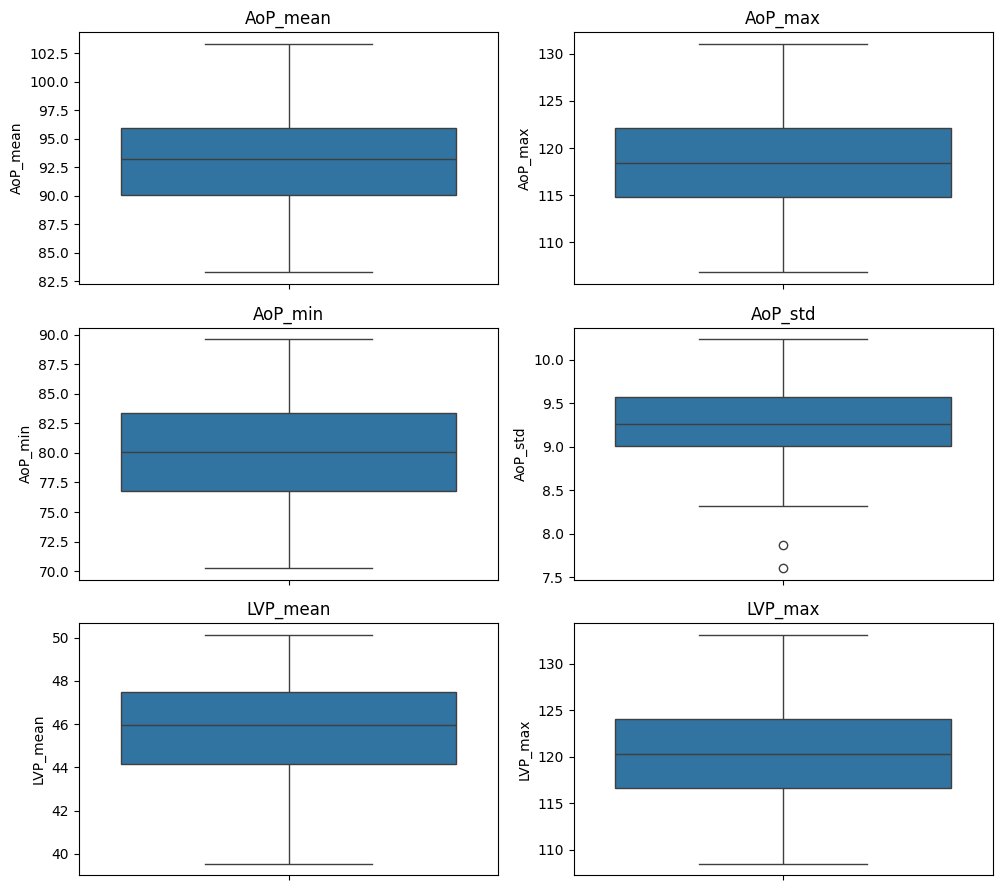

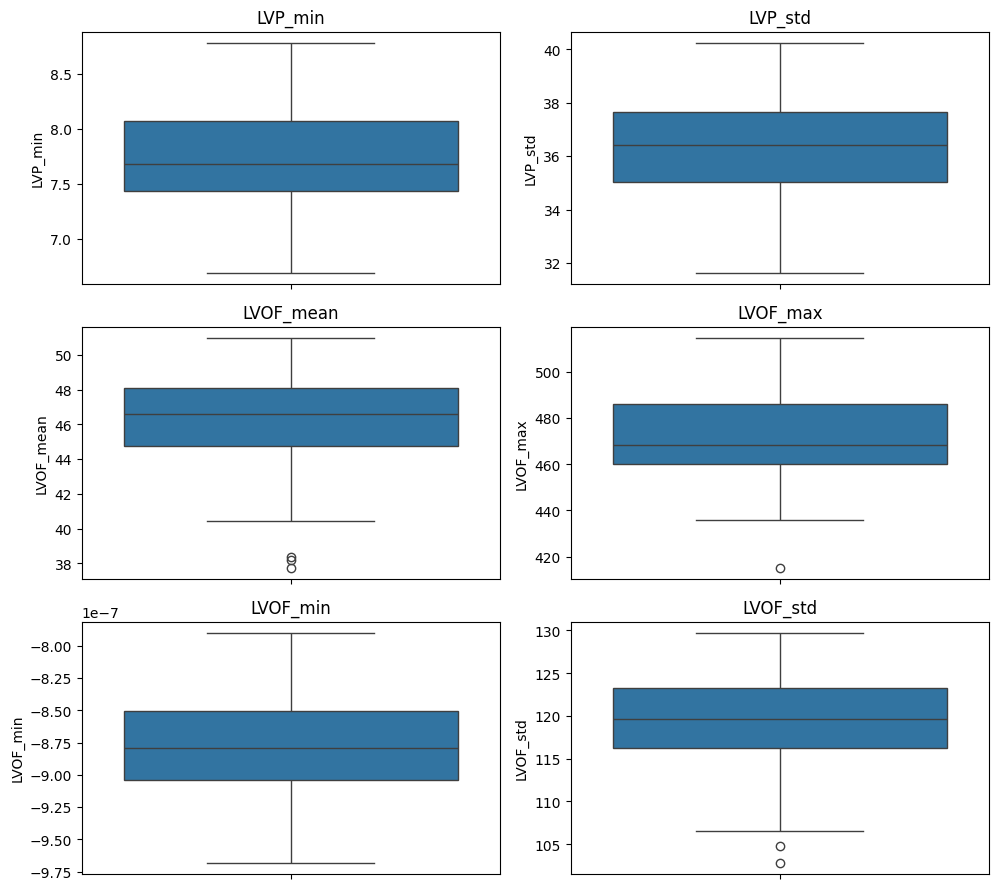

In [ ]:
# Select only numerical columns
num_cols = pe.select_dtypes(include=['int64', 'float64']).columns

# Set number of plots per figure
plots_per_fig = 6
num_figs = math.ceil(len(num_cols) / plots_per_fig)

for i in range(num_figs):
    subset = num_cols[i*plots_per_fig:(i+1)*plots_per_fig]
    n_rows = math.ceil(len(subset) / 2)  # 2 columns per row

    fig, axes = plt.subplots(n_rows, 2, figsize=(10, 3*n_rows))
    axes = axes.flatten()

    for ax, col in zip(axes, subset):
        sns.boxplot(y=pe[col], ax=ax)
        ax.set_title(f'{col}')

    # Hide any unused subplots
    for j in range(len(subset), len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

In [ ]:
# Initialize scaler
scaler = RobustScaler()



X = pe.drop(columns=["patientIndex", "PtKey", "tc"])

X[X.columns] = scaler.fit_transform(X[X.columns])

# Convert back to dataframe
X_scaled_df = pd.DataFrame(X, columns=X.columns)

X_scaled_df.describe()


,BSA,HR,HI,LVEDVi,LVESVi,RVEDVi,RVESVi,SV,CO,AoP_mean,...,AoP_min,AoP_std,LVP_mean,LVP_max,LVP_min,LVP_std,LVOF_mean,LVOF_max,LVOF_min,LVOF_std
count,61.000000,61.000000,61.000000,61.000000,61.000000,61.000000,61.000000,61.000000,61.000000,61.000000,...,61.000000,61.000000,61.000000,61.000000,61.000000,61.000000,61.000000,61.000000,61.000000,61.000000
mean,-0.016393,-0.190416,0.150522,0.030800,0.033242,-0.081662,-0.016927,-0.034664,0.049337,-0.017516,...,0.006851,-0.036107,-0.094727,0.010961,0.043757,-0.058594,-0.135525,0.104073,0.027290,-0.038217
std,0.758107,0.933130,1.055862,0.720334,0.857505,0.708349,1.094945,0.933868,0.723989,0.792489,...,0.686361,0.885500,0.760913,0.760452,0.723364,0.718380,0.905810,0.755306,0.764603,0.846776
min,-2.000000,-2.384615,-1.318182,-1.775758,-2.041667,-1.762791,-1.926829,-2.905482,-1.616548,-1.698792,...,-1.481098,-2.990858,-1.928737,-1.575121,-1.536288,-1.845938,-2.659485,-2.038731,-1.666471,-2.430956
25%,-0.500000,-0.615385,-0.545455,-0.430303,-0.500000,-0.651163,-0.658537,-0.505326,-0.461038,-0.531558,...,-0.504143,-0.452610,-0.535689,-0.489731,-0.381161,-0.528229,-0.561787,-0.311527,-0.468267,-0.492528
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.500000,0.384615,0.454545,0.569697,0.500000,0.348837,0.341463,0.494674,0.538962,0.468442,...,0.495857,0.547390,0.464311,0.510269,0.618839,0.471771,0.438213,0.688473,0.531733,0.507472
max,2.000000,1.615385,4.954545,1.454545,2.125000,1.851163,6.186992,2.127505,1.707141,1.733765,...,1.432045,1.752588,1.258606,1.718285,1.720372,1.469280,1.307273,1.778379,1.655060,1.441628


The total explained variance is: 87.39%


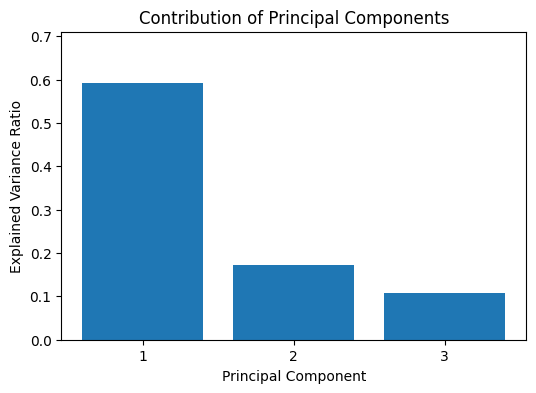

In [ ]:


pca = PCA(n_components = 3)
X_pca = pca.fit_transform(X_scaled_df)
# See explained variance
print("The total explained variance is: {:.2f}%".format(pca.explained_variance_ratio_.sum() * 100))

explained_variance_ratio = pca.explained_variance_ratio_

plt.figure(figsize=(6,4))
plt.bar(
    x=np.arange(1, len(explained_variance_ratio) + 1),
    height=explained_variance_ratio
)
plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.title("Contribution of Principal Components")
plt.xticks(np.arange(1, len(explained_variance_ratio) + 1))
plt.ylim(0, max(explained_variance_ratio) * 1.2)

plt.show()

X_pca_df = pd.DataFrame(X_pca, columns=["PC1", "PC2", "PC3"])


- First three principle components explained 87% of the variance in the data

In [ ]:
pc_scores = X_scaled_df @ pca.components_.T

# Compute correlation matrix between features and PCs
corr_matrix = np.corrcoef(X_scaled_df.T, pc_scores.T)[
    :X_scaled_df.shape[1],   # top block: features
    X_scaled_df.shape[1]:    # right block: PCs
]

corr_df = pd.DataFrame(
    corr_matrix,
    index=X_scaled_df.columns,
    columns=[f"PC{i+1}" for i in range(pc_scores.shape[1])]
)

print(corr_df)

                PC1       PC2       PC3
BSA        0.526472  0.267541 -0.359744
HR         0.304550  0.929202 -0.111087
HI        -0.318444  0.381103  0.753808
LVEDVi     0.796965 -0.260098  0.284493
LVESVi     0.604182 -0.211828  0.398630
RVEDVi     0.759604 -0.159848  0.433594
RVESVi     0.571804 -0.074966  0.521628
SV         0.507230 -0.808996  0.140763
CO         0.925828  0.362067 -0.014253
AoP_mean   0.944438  0.316200  0.024257
AoP_max    0.964603  0.239070  0.035447
AoP_min    0.883943  0.463946  0.002892
AoP_std    0.676444 -0.717092 -0.062878
LVP_mean   0.955067  0.074268 -0.200757
LVP_max    0.965105  0.236700  0.035636
LVP_min    0.970459  0.036884  0.142774
LVP_std    0.943621  0.300443 -0.117428
LVOF_mean  0.838106 -0.175020 -0.426948
LVOF_max   0.959066 -0.184150  0.075005
LVOF_min  -0.956018 -0.276665 -0.028225
LVOF_std   0.955666 -0.149766 -0.228580


In [ ]:
for pc in corr_df.columns:
    top3 = corr_df[pc].abs().sort_values(ascending=False)
    print(f"{pc}:")
    for feature in top3.index:
        print(f"  {feature} (correlation = {corr_df[pc].loc[feature]:.3f})")


PC1:
  LVP_min (correlation = 0.970)
  LVP_max (correlation = 0.965)
  AoP_max (correlation = 0.965)
  LVOF_max (correlation = 0.959)
  LVOF_min (correlation = -0.956)
  LVOF_std (correlation = 0.956)
  LVP_mean (correlation = 0.955)
  AoP_mean (correlation = 0.944)
  LVP_std (correlation = 0.944)
  CO (correlation = 0.926)
  AoP_min (correlation = 0.884)
  LVOF_mean (correlation = 0.838)
  LVEDVi (correlation = 0.797)
  RVEDVi (correlation = 0.760)
  AoP_std (correlation = 0.676)
  LVESVi (correlation = 0.604)
  RVESVi (correlation = 0.572)
  BSA (correlation = 0.526)
  SV (correlation = 0.507)
  HI (correlation = -0.318)
  HR (correlation = 0.305)
PC2:
  HR (correlation = 0.929)
  SV (correlation = -0.809)
  AoP_std (correlation = -0.717)
  AoP_min (correlation = 0.464)
  HI (correlation = 0.381)
  CO (correlation = 0.362)
  AoP_mean (correlation = 0.316)
  LVP_std (correlation = 0.300)
  LVOF_min (correlation = -0.277)
  BSA (correlation = 0.268)
  LVEDVi (correlation = -0.260)
  Ao

## *** PC Interpretation

PC1: LV and Aortic pressures, LV and RV diastolic & systolic volumes
(Heart pressure and cardiac size/volume)

PC2: Heart Rate, Stroke Volume, Cardiac Output
(Heart rate and pacing to maintain cardiac output)

PC3: HI, LVOF_min, RVESVi
(Chest Wall Deformity and Ventricular Constraint (Haller Index))

**===== PC1 =====**
- LVP (+++)
- LVOF (+++)
- AoP (++)
- CO (++)

Explanation: Mostly focused around heart's OUTPUT, specifically oxygenated bloods to the rest of the body (aortic pressure)

Higher - better oxygenated blood distribution
Lower - poorer overall cardiac performance

**===== PC2 =====**
- HR (+++)
- SV (---)

Explanation: Mostly tradeoff between how quickly heart pumps out blood, which in turn reduces stroke volume.

Higher - more stress on the heart to continuously pump blood
Lower - more efficient, better performance

**===== PC3 =====**
- HI (+++)
- RVESVi (++)
- RVEDVi (++)
- LVOF_mean (--)

- Higher values may indicate compensation, higher right side indicates a bigger attempt to compensate for possible decreased performance (HI)

Higher - more compensation, heart is working harder to compensate for stress
Lower - less compensation, better performance overall




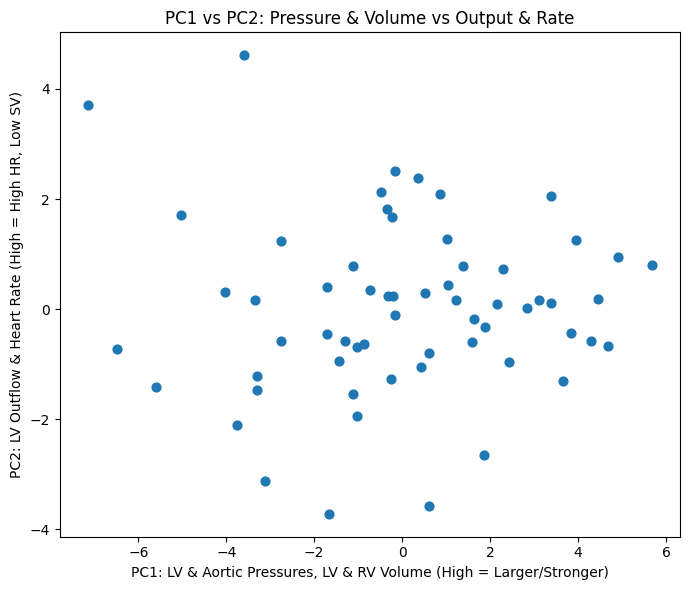

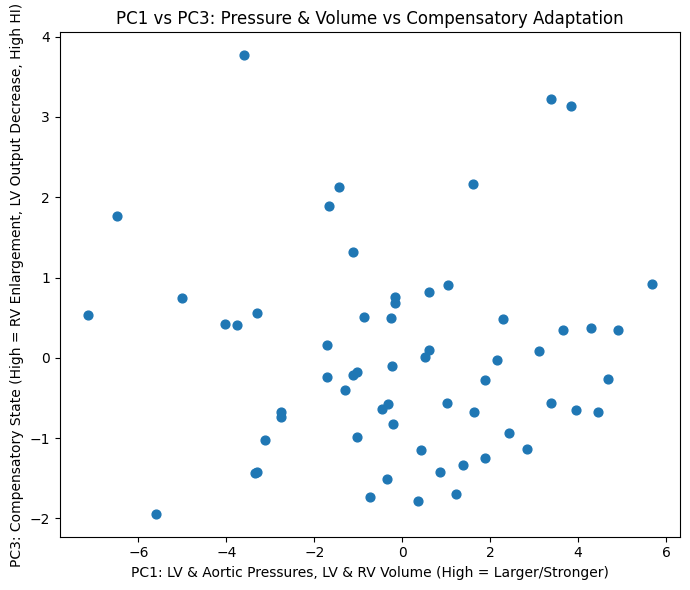

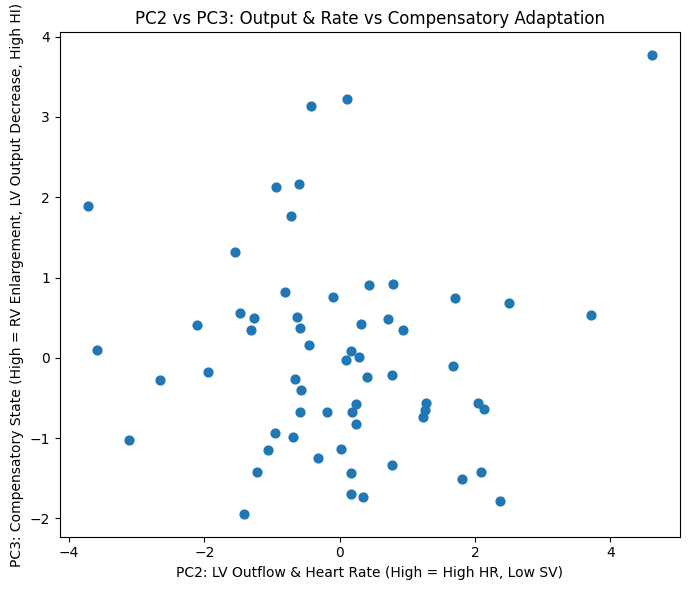

In [ ]:
# --- PC1 vs PC2 ---
plt.figure(figsize=(7, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], s=40)
plt.xlabel("PC1: LV & Aortic Pressures, LV & RV Volume (High = Larger/Stronger)")
plt.ylabel("PC2: LV Outflow & Heart Rate (High = High HR, Low SV)")
plt.title("PC1 vs PC2: Pressure & Volume vs Output & Rate")
plt.tight_layout()
plt.show()

# --- PC1 vs PC3 ---
plt.figure(figsize=(7, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 2], s=40)
plt.xlabel("PC1: LV & Aortic Pressures, LV & RV Volume (High = Larger/Stronger)")
plt.ylabel("PC3: Compensatory State (High = RV Enlargement, LV Output Decrease, High HI)")
plt.title("PC1 vs PC3: Pressure & Volume vs Compensatory Adaptation")
plt.tight_layout()
plt.show()

# --- PC2 vs PC3 ---
plt.figure(figsize=(7, 6))
plt.scatter(X_pca[:, 1], X_pca[:, 2], s=40)
plt.xlabel("PC2: LV Outflow & Heart Rate (High = High HR, Low SV)")
plt.ylabel("PC3: Compensatory State (High = RV Enlargement, LV Output Decrease, High HI)")
plt.title("PC2 vs PC3: Output & Rate vs Compensatory Adaptation")
plt.tight_layout()
plt.show()


# Clustering Methods

## Finding Optimal Value of k

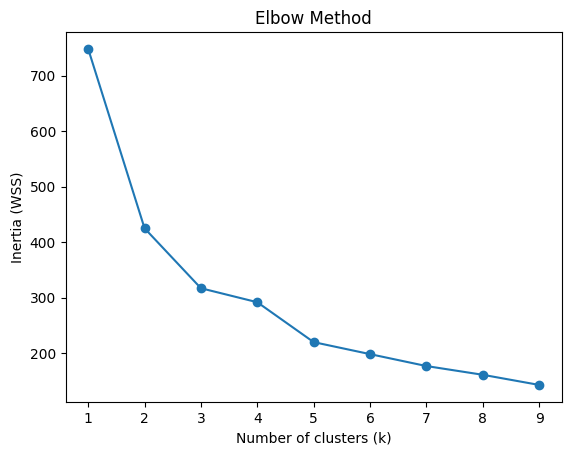

[748.1277377005599,
 424.87171184462034,
 316.8868686911555,
 291.6487269080908,
 219.75507476420628,
 198.13628481656667,
 176.6589233283912,
 160.91501068257978,
 142.64233716152387]

In [ ]:
# Elbow method

inertia = []
K = range(1, 10)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_pca)  # use your 3 PCs
    inertia.append(kmeans.inertia_)

plt.plot(K, inertia, marker='o')
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia (WSS)")
plt.title("Elbow Method")
plt.show()
inertia

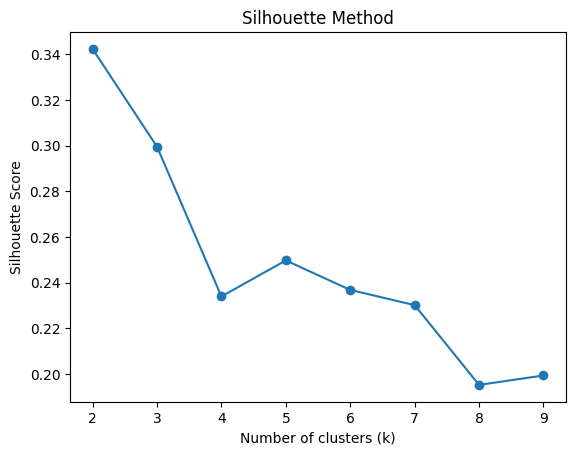

[np.float64(0.34233672390164716),
 np.float64(0.2995399025926224),
 np.float64(0.23394047945010735),
 np.float64(0.2497314007504404),
 np.float64(0.23682163779526452),
 np.float64(0.23016812413655863),
 np.float64(0.1952205731816556),
 np.float64(0.19935631198755974)]

In [ ]:
# Sihoutte Score (Separation + Compactnestt)
sil = []
K = range(2, 10)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_pca)
    sil.append(silhouette_score(X_pca, labels))

plt.plot(K, sil, marker='o')
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Method")
plt.show()
sil

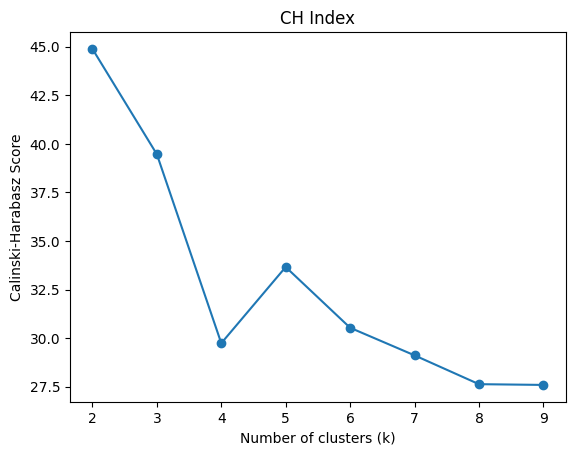

[np.float64(44.88909238672798),
 np.float64(39.46514178049241),
 np.float64(29.738176116880915),
 np.float64(33.66118979980803),
 np.float64(30.534063901142037),
 np.float64(29.113838307441682),
 np.float64(27.62973572192502),
 np.float64(27.5910727615681)]

In [ ]:
ch_scores = []
K = range(2, 10)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_pca)
    ch_scores.append(calinski_harabasz_score(X_pca, labels))

plt.plot(K, ch_scores, marker='o')
plt.xlabel("Number of clusters (k)")
plt.ylabel("Calinski-Harabasz Score")
plt.title("CH Index")
plt.show()

ch_scores


## K-Means

In [ ]:
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X_pca)
df_pca_kmeans = pd.DataFrame(X_pca, columns=['PC1','PC2','PC3'])
df_pca_kmeans['cluster'] = clusters

In [ ]:
fig = go.Figure()

colors = {0: "rgba(255,0,0,0.3)",
          1: "rgba(0,255,0,0.3)",
          2: "rgba(0,0,255,0.3)"}

# Add point scatter
fig.add_trace(go.Scatter3d(
    x=df_pca_kmeans["PC1"],
    y=df_pca_kmeans["PC2"],
    z=df_pca_kmeans["PC3"],
    mode="markers",
    marker=dict(size=4, color=df_pca_kmeans["cluster"], colorscale="Viridis"),
    name="Points"
))

# Add convex hull for each cluster
for c in df_pca_kmeans["cluster"].unique():
    points = df_pca_kmeans[df_pca_kmeans["cluster"] == c][["PC1","PC2","PC3"]].values

    if len(points) >= 4:  # convex hull needs >=4 points
        hull = ConvexHull(points)
        vertices = hull.vertices

        fig.add_trace(go.Mesh3d(
            x=points[vertices, 0],
            y=points[vertices, 1],
            z=points[vertices, 2],
            opacity=0.2,
            color=colors[c],
            name=f"Cluster {c} Hull"
        ))

fig.update_layout(
    scene=dict(
        xaxis_title="PC1: Cardiac–Pulmonary Power (High = Strong Heart + Large Lungs)",
        yaxis_title="PC2: Heart vs Lung Tradeoff (High = Bigger Heart, Lower Lung Function)",
        zaxis_title="PC3: Compensatory State (High = RV Enlargement, LV Output Decrease, High HI)"
    ),
    width=900,
    height=800
)

fig.show()


Cluster 0 - Overall lower cardiac/pulmonary power, but better balance

Cluster 1 - Ok cardiac/pulmonary power, reduced heart filling

Cluster 2 - high cardiac/pumlonary power, reduced heart filling

In [ ]:
## EDIT LABEL TO BE SHORTER

fig = go.Figure()

points_colors = {
    0: "red",
    1: "green",
    2: "blue"
}

colors = {0: "rgba(255, 0, 0, 255)",
          1: "rgba(0,255,0,255)",
          2: "rgba(0,0,255,255)"}

# Add point scatter
fig.add_trace(go.Scatter3d(
    x=df_pca_kmeans["PC1"],
    y=df_pca_kmeans["PC2"],
    z=df_pca_kmeans["PC3"],
    mode="markers",
    marker=dict(size=4, color=df_pca_kmeans["cluster"].map(points_colors)),
    name="Points"
))

# Add convex hull for each cluster
for c in df_pca_kmeans["cluster"].unique():
    points = df_pca_kmeans[df_pca_kmeans["cluster"] == c][["PC1","PC2","PC3"]].values

    if len(points) >= 4:  # convex hull needs >=4 points
        hull = ConvexHull(points)
        vertices = hull.vertices

        fig.add_trace(go.Mesh3d(
            x=points[vertices, 0],
            y=points[vertices, 1],
            z=points[vertices, 2],
            opacity=0.2,
            color=colors[c],
            name=f"Cluster {c} Hull"
        ))

fig.update_layout(
    scene=dict(
        xaxis_title="PC1: Cardiac Output",
        yaxis_title="PC2: Pumping Efficiency",
        zaxis_title="PC3: Compensatory Load"
    ),
    width=900,
    height=800
)

fig.show()


## Agglomerative Clustering

In [ ]:
agg = AgglomerativeClustering(
    n_clusters=3,        # same as K-means choice
    linkage='ward'       # Ward is best for continuous data + PCA
)

clusters = agg.fit_predict(X_pca)

# Build the PCA dataframe with cluster labels
df_pca = pd.DataFrame(X_pca, columns=['PC1', 'PC2', 'PC3'])
df_pca['cluster'] = clusters

df_pca.head()

,PC1,PC2,PC3,cluster
0,4.908296,0.940275,0.351196,1
1,1.599334,-0.595401,2.161196,1
2,5.677438,0.793451,0.919884,1
3,3.114037,0.168152,0.083929,1
4,3.386877,0.115616,3.229186,1


In [ ]:
fig = go.Figure()

colors = {0: "rgba(255,0,0,0.3)",
          1: "rgba(0,255,0,0.3)",
          2: "rgba(0,0,255,0.3)"}

# Add point scatter
fig.add_trace(go.Scatter3d(
    x=df_pca["PC1"],
    y=df_pca["PC2"],
    z=df_pca["PC3"],
    mode="markers",
    marker=dict(size=4, color=df_pca["cluster"], colorscale="Viridis"),
    name="Points"
))

# Add convex hull for each cluster
for c in df_pca["cluster"].unique():
    points = df_pca[df_pca["cluster"] == c][["PC1","PC2","PC3"]].values

    if len(points) >= 4:  # convex hull needs >=4 points
        hull = ConvexHull(points)
        vertices = hull.vertices

        fig.add_trace(go.Mesh3d(
            x=points[vertices, 0],
            y=points[vertices, 1],
            z=points[vertices, 2],
            opacity=0.2,
            color=colors[c],
            name=f"Cluster {c} Hull"
        ))

fig.update_layout(
    scene=dict(
        xaxis_title="PC1: LV & Aortic Pressures + Ventricular Volumes (High = Strong Heart)",
        yaxis_title="PC2: LV Outflow & Heart Rate (High = High HR, Low Stroke Volume)",
        zaxis_title="PC3: Ventricular Compensation (High = Better Filling / Efficiency)"
    ),
    width=900,
    height=800
)

fig.show()


# Hypothesis Testing

- LVP (+++)
- LVOF (+++)
- AoP (++)
- CO (++)

Explanation: Mostly focused around heart's OUTPUT, specifically oxygenated bloods to the rest of the body (aortic pressure)

Higher - better oxygenated blood distribution
Lower - poorer overall cardiac performance

**===== PC2 =====**
- HR (+++)
- SV (---)

Explanation: Mostly tradeoff between how quickly heart pumps out blood, which in turn reduces stroke volume.

Higher - more stress on the heart to continuously pump blood
Lower - more efficient, better performance

**===== PC3 =====**
- HI (+++)
- RVESVi (++)
- RVEDVi (++)
- LVOF_mean (--)


LVP, LVOF, AoP, CO, HR, SV, HI, RVESVi, RVEDVi, LVOF_mean

In [ ]:
df_pe_cluster = pe.merge(df_pca_kmeans, left_index=True, right_index=True)
df_pe_cluster.columns

Index(['patientIndex', 'PtKey', 'BSA', 'HR', 'tc', 'HI', 'LVEDVi', 'LVESVi',
       'RVEDVi', 'RVESVi', 'SV', 'CO', 'AoP_mean', 'AoP_max', 'AoP_min',
       'AoP_std', 'LVP_mean', 'LVP_max', 'LVP_min', 'LVP_std', 'LVOF_mean',
       'LVOF_max', 'LVOF_min', 'LVOF_std', 'PC1', 'PC2', 'PC3', 'cluster'],
      dtype='object')

In [ ]:
,

''

In [ ]:
df_pe_cluster['cluster'].value_counts()

,count
cluster,
1,28
2,17
0,15


In [ ]:
labels = df_pe_cluster["cluster"]

In [ ]:
TITLE_FS = 24
LABEL_FS = 20
TICK_FS = 18

# Lighter colors as RGBA tuples (R,G,B,A) with values 0–1
box_colors = {
    0: (1.0, 0.4, 0.4, 0.6),  # light red
    1: (0.4, 1.0, 0.4, 0.6),  # light green
    2: (0.4, 0.4, 1.0, 0.6)   # light blue
}

## Principal Component #1

In [ ]:
cols = ["CO"]

results = {}

for col in cols:
    groups = [df_pe_cluster.loc[labels == g, col].dropna() for g in labels.unique()]

    # Kruskal–Wallis test
    stat, p = kruskal(*groups)
    results[col] = (stat, p)

for col, (stat, p) in results.items():
    print(col, stat, p)

CO 18.0210974881756 0.00012211482784024803


In [ ]:
for col in cols:
    data = df_pe_cluster[[col, "cluster"]].dropna()
    # Dunn's test with Bonferroni correction
    dunn_res = sp.posthoc_dunn(data, val_col=col, group_col="cluster", p_adjust='bonferroni')
    print(f"\nDunn post-hoc for {col}:\n", dunn_res)


Dunn post-hoc for CO:
           0         1         2
0  1.000000  0.010898  0.000076
1  0.010898  1.000000  0.203771
2  0.000076  0.203771  1.000000


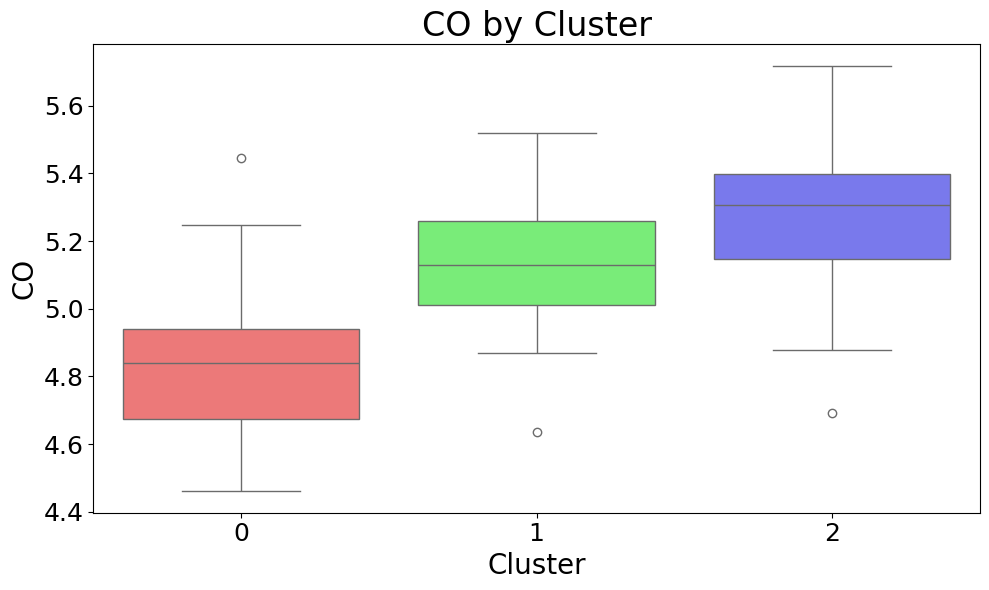

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(10,6))

# BSA boxplot
sns.boxplot(
    x="cluster", y="CO", data=df_pe_cluster,
    hue="cluster", palette=box_colors, legend=False, ax=ax
)

ax.set_title("CO by Cluster", fontsize=TITLE_FS)
ax.set_xlabel("Cluster", fontsize=LABEL_FS)
ax.set_ylabel("CO", fontsize=LABEL_FS)
ax.tick_params(axis='both', labelsize=TICK_FS)

plt.tight_layout()
plt.show()


## Principal Component #2

In [ ]:
cols = ["HR", "SV"]

results = {}

for col in cols:
    groups = [df_pe_cluster.loc[labels == g, col].dropna() for g in labels.unique()]

    # Kruskal–Wallis test
    stat, p = kruskal(*groups)
    results[col] = (stat, p)

for col, (stat, p) in results.items():
    print(col, stat, p)

HR 7.052570178964893 0.029413983469971067
SV 11.340590531294481 0.003446847390211543


In [ ]:
for col in cols:
    data = df_pe_cluster[[col, "cluster"]].dropna()
    # Dunn's test with Bonferroni correction
    dunn_res = sp.posthoc_dunn(data, val_col=col, group_col="cluster", p_adjust='bonferroni')
    print(f"\nDunn post-hoc for {col}:\n", dunn_res)


Dunn post-hoc for HR:
           0         1         2
0  1.000000  0.024184  0.264743
1  0.024184  1.000000  1.000000
2  0.264743  1.000000  1.000000

Dunn post-hoc for SV:
           0         1         2
0  1.000000  1.000000  0.076242
1  1.000000  1.000000  0.002633
2  0.076242  0.002633  1.000000


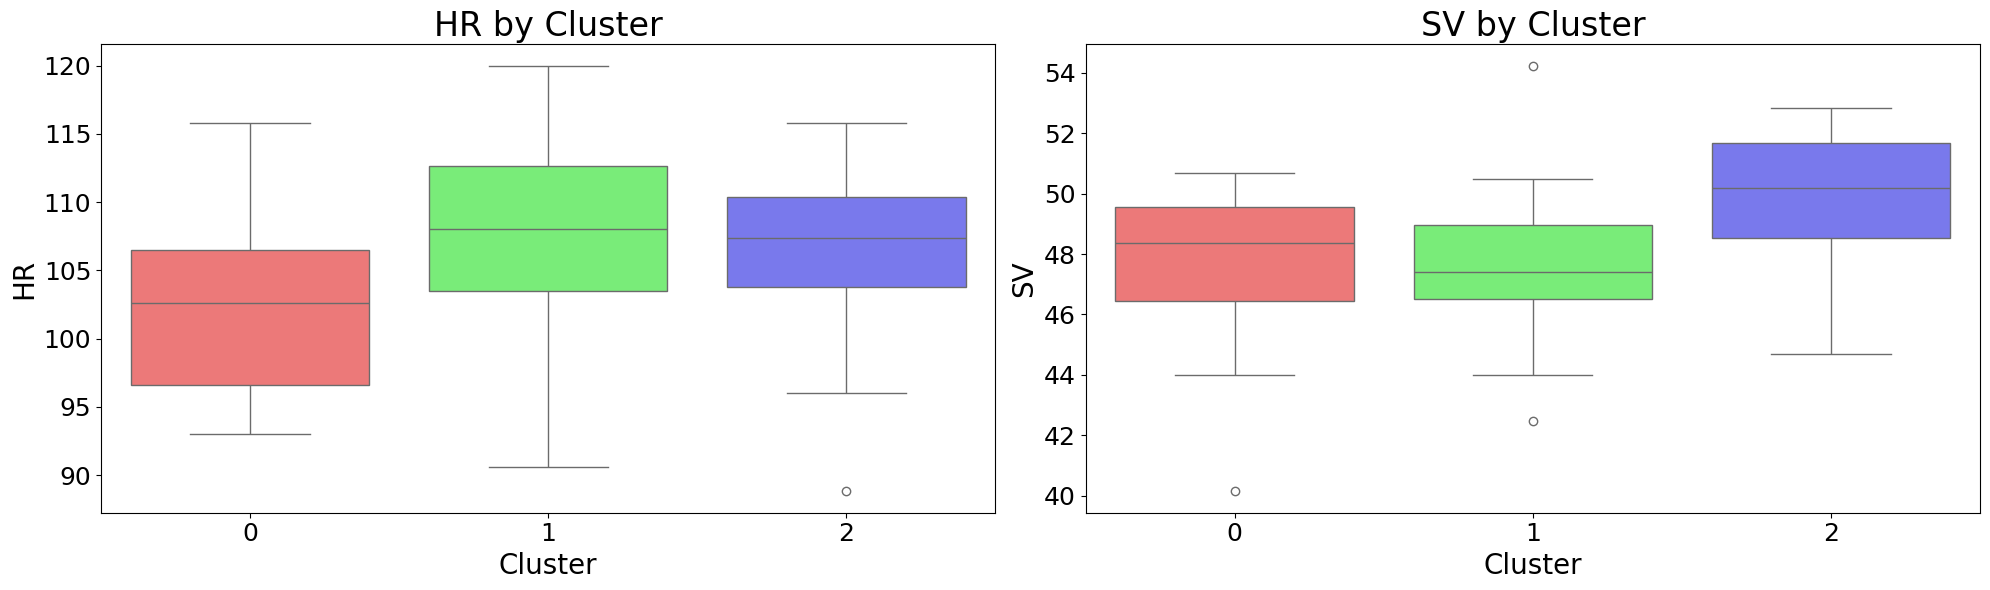

In [ ]:
fig, axes = plt.subplots(1, len(cols), figsize=(20,6))

for i, col in enumerate(cols):
    sns.boxplot(
        x="cluster", y=col, data=df_pe_cluster,
        hue="cluster", palette=box_colors, legend=False, ax=axes[i]
    )
    axes[i].set_title(f"{col} by Cluster", fontsize=TITLE_FS)
    axes[i].set_xlabel("Cluster", fontsize=LABEL_FS)
    axes[i].set_ylabel(col, fontsize=LABEL_FS)
    axes[i].tick_params(axis='both', labelsize=TICK_FS)

plt.tight_layout()
plt.show()


## Principal Component #3

In [ ]:
cols = ["HI", "RVESVi", "RVEDVi"]

results = {}

for col in cols:
    groups = [df_pe_cluster.loc[labels == g, col].dropna() for g in labels.unique()]

    # Kruskal–Wallis test
    stat, p = kruskal(*groups)
    results[col] = (stat, p)

for col, (stat, p) in results.items():
    print(col, stat, p)

HI 1.9949396258252887 0.368811423530863
RVESVi 13.52967843624512 0.0011536329626425266
RVEDVi 11.546665446216279 0.003109377532615504


In [ ]:
cols = ["RVESVi", "RVEDVi"]

for col in cols:
    data = df_pe_cluster[[col, "cluster"]].dropna()
    # Dunn's test with Bonferroni correction
    dunn_res = sp.posthoc_dunn(data, val_col=col, group_col="cluster", p_adjust='bonferroni')
    print(f"\nDunn post-hoc for {col}:\n", dunn_res)


Dunn post-hoc for RVESVi:
           0         1         2
0  1.000000  0.640507  0.001241
1  0.640507  1.000000  0.016622
2  0.001241  0.016622  1.000000

Dunn post-hoc for RVEDVi:
           0         1         2
0  1.000000  1.000000  0.004703
1  1.000000  1.000000  0.017598
2  0.004703  0.017598  1.000000


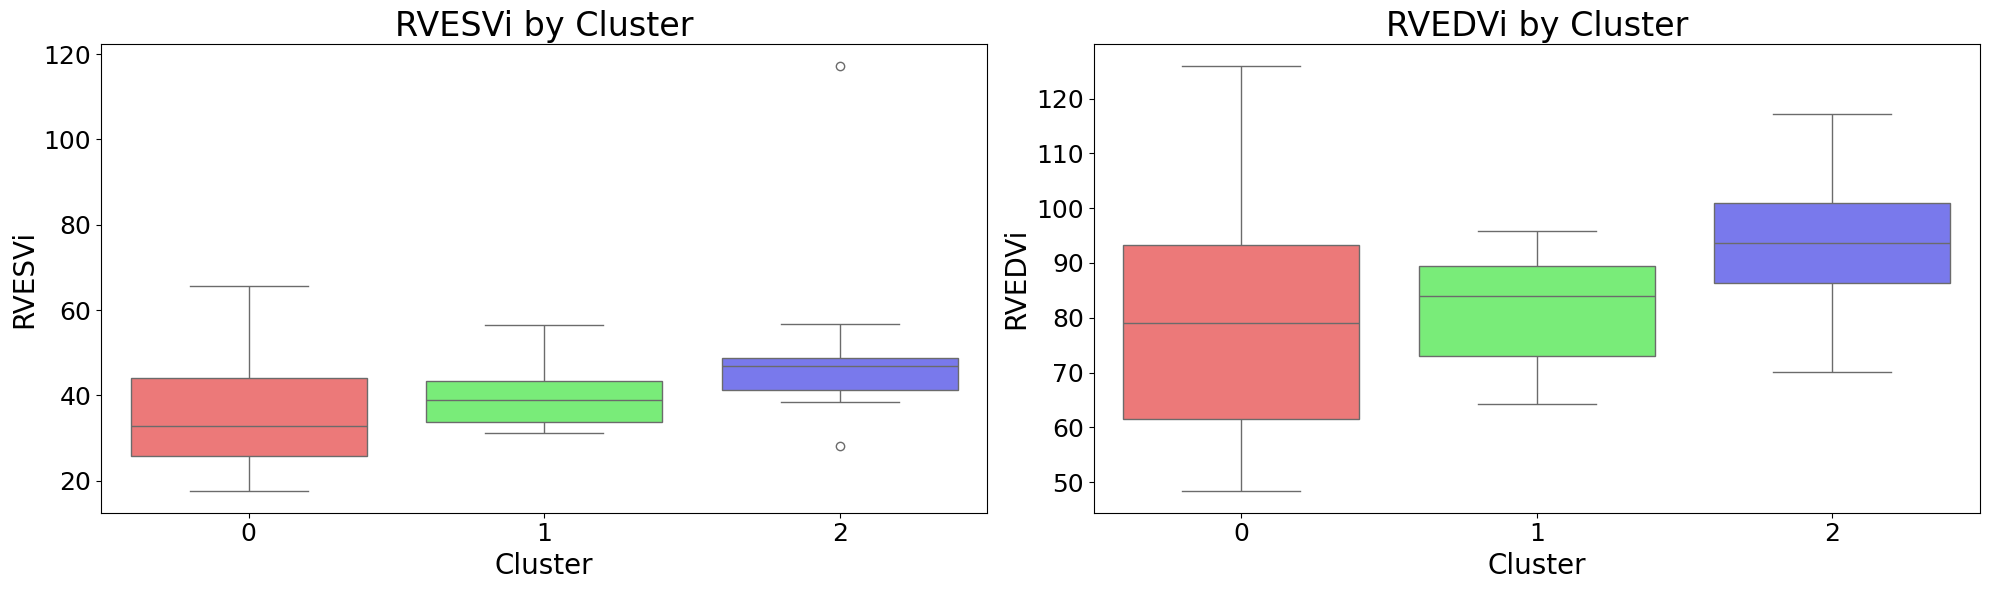

In [ ]:
fig, axes = plt.subplots(1, len(cols), figsize=(20,6))

for i, col in enumerate(cols):
    sns.boxplot(
        x="cluster", y=col, data=df_pe_cluster,
        hue="cluster", palette=box_colors, legend=False, ax=axes[i]
    )
    axes[i].set_title(f"{col} by Cluster", fontsize=TITLE_FS)
    axes[i].set_xlabel("Cluster", fontsize=LABEL_FS)
    axes[i].set_ylabel(col, fontsize=LABEL_FS)
    axes[i].tick_params(axis='both', labelsize=TICK_FS)

plt.tight_layout()
plt.show()


## Extra - LVESVi/LVEDVi
Just checking since RVESVi and RVEDVi have significant differences

In [ ]:
cols = ["LVESVi", "LVEDVi"]

results = {}

for col in cols:
    groups = [df_pe_cluster.loc[labels == g, col].dropna() for g in labels.unique()]

    # Kruskal–Wallis test
    stat, p = kruskal(*groups)
    results[col] = (stat, p)

for col, (stat, p) in results.items():
    print(col, stat, p)

LVESVi 15.571998497842687 0.00041551192283861686
LVEDVi 16.381943785712114 0.00027714439864513605


In [ ]:
for col in cols:
    data = df_pe_cluster[[col, "cluster"]].dropna()
    # Dunn's test with Bonferroni correction
    dunn_res = sp.posthoc_dunn(data, val_col=col, group_col="cluster", p_adjust='bonferroni')
    print(f"\nDunn post-hoc for {col}:\n", dunn_res)


Dunn post-hoc for LVESVi:
           0         1         2
0  1.000000  0.193643  0.000281
1  0.193643  1.000000  0.029844
2  0.000281  0.029844  1.000000

Dunn post-hoc for LVEDVi:
           0         1         2
0  1.000000  0.380946  0.000256
1  0.380946  1.000000  0.009879
2  0.000256  0.009879  1.000000


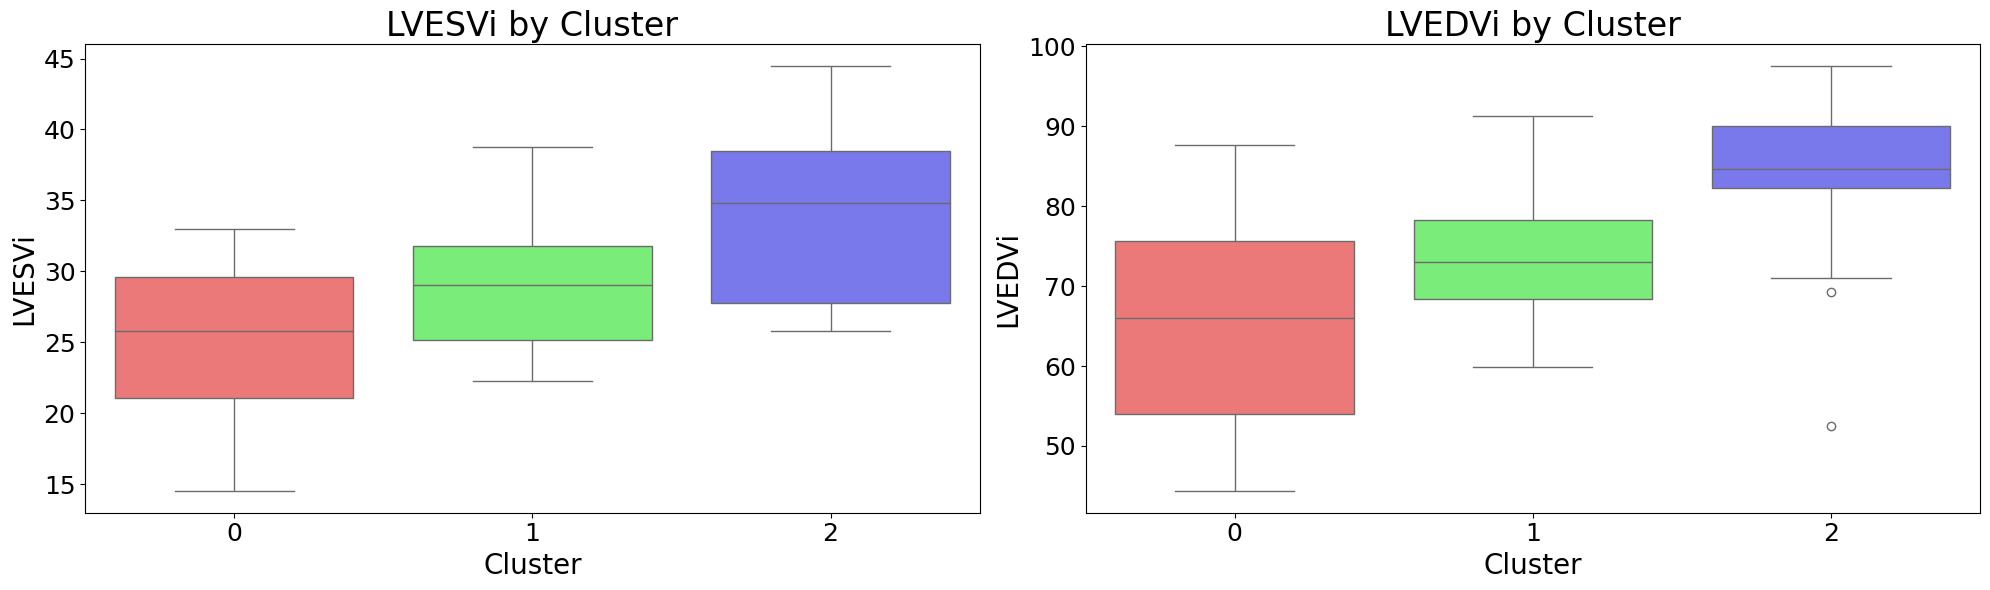

In [ ]:
fig, axes = plt.subplots(1, len(cols), figsize=(20,6))

for i, col in enumerate(cols):
    sns.boxplot(
        x="cluster", y=col, data=df_pe_cluster,
        hue="cluster", palette=box_colors, legend=False, ax=axes[i]
    )
    axes[i].set_title(f"{col} by Cluster", fontsize=TITLE_FS)
    axes[i].set_xlabel("Cluster", fontsize=LABEL_FS)
    axes[i].set_ylabel(col, fontsize=LABEL_FS)
    axes[i].tick_params(axis='both', labelsize=TICK_FS)

plt.tight_layout()
plt.show()


# Conclusions

**========== Group 0 ==========**

Distinctly different in cardiac output

- Lower values of RVESVi, RVEDVi, LVESVi, and LVEDVi
- Lowest CO and HR

_This could mean that this set of patients exhibits lowest performance of the heart, with lowest cardiac output and heart rate_

**========== Group 1 ==========**

Distinctly different from group 0 in heart rate

- Moderate HR, CO, RVESVi, RVEDVi, LVESVi, and LVEDVi

_Moderate group? slighter better heart rate, but still low values of ventricular volumes (RVESVi, RVEDVi, LVESVi, and LVEDVi)_

**========== Group 2 ==========**

Distinctly different in RVESVi, RVEDVi, LVESVi, and LVEDVi

- Highest cardiac output and SV
- Higher HR
- Highest values of ventricular volumes

_We suggest that this grouping represents better heart performance_
